# 🏦 Analisi del Rischio di Credito
## Credit Risk Analysis — Python + SQL + Power BI

**Dataset:** German Credit Dataset (UCI ML Repository)  
**Strumenti:** Python, SQLite, Scikit-learn, Power BI  
**Autore:** Jhon Edward Gafaro Nieto  
**GitHub:** github.com/edwardgafaro  

---

### Obiettivo
Costruire un sistema completo di analisi del rischio creditizio:
dalla pulizia dei dati con SQL, all'analisi esplorativa in Python,
fino a un modello predittivo e una dashboard esecutiva in Power BI.

## 1. Importazione Librerie e Caricamento Dati

In [1]:
# Librerie standard
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# SQL
import sqlite3
from sqlalchemy import create_engine, text

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

# Configurazione grafica
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("✅ Librerie importate correttamente")

✅ Librerie importate correttamente


In [2]:
# Caricamento dataset
df = pd.read_csv(r'C:\Users\jedwa\OneDrive\Data Analyst\Project Works personali\credit-risk-analysis\data\credit_data.csv')

print("Shape:", df.shape)
print("\nColonne:")
print(df.columns.tolist())
print("\nTipi di dati:")
print(df.dtypes)
print("\nPrime 5 righe:")
df.head()

Shape: (1000, 11)

Colonne:
['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']

Tipi di dati:
Unnamed: 0           int64
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object

Prime 5 righe:


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


## 2. Creazione Database SQL e Pulizia dei Dati

In [3]:
# Creazione database SQLite
engine = create_engine('sqlite:///../data/credit_clean.db')

# Caricamento dati nel database
df.to_sql('credito', engine, if_exists='replace', index=False)

print("✅ Database SQLite creato: credit_clean.db")
print("✅ Tabella 'credito' caricata con", len(df), "righe")

# Verifica connessione
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) as totale FROM credito"))
    print("✅ Record nel database:", result.fetchone()[0])

✅ Database SQLite creato: credit_clean.db
✅ Tabella 'credito' caricata con 1000 righe
✅ Record nel database: 1000


In [4]:
# Funzione helper per eseguire query SQL e restituire DataFrame
def esegui_query(sql):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

# Prima query — distribuzione del rischio
query_rischio = """
SELECT 
    Risk AS rischio,
    COUNT(*) AS totale_clienti,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM credito), 1) AS percentuale
FROM credito
GROUP BY Risk
ORDER BY totale_clienti DESC
"""

df_rischio = esegui_query(query_rischio)
print("=== DISTRIBUZIONE RISCHIO CREDITIZIO ===")
print(df_rischio.to_string(index=False))

=== DISTRIBUZIONE RISCHIO CREDITIZIO ===
rischio  totale_clienti  percentuale
   good             700         70.0
    bad             300         30.0


In [5]:
# Query 1 — Rischio per fascia d'età
query_eta = """
SELECT 
    CASE 
        WHEN Age < 25 THEN '18-24'
        WHEN Age BETWEEN 25 AND 34 THEN '25-34'
        WHEN Age BETWEEN 35 AND 44 THEN '35-44'
        WHEN Age BETWEEN 45 AND 54 THEN '45-54'
        ELSE '55+'
    END AS fascia_eta,
    COUNT(*) AS totale,
    SUM(CASE WHEN Risk = 'bad' THEN 1 ELSE 0 END) AS rischio_alto,
    ROUND(SUM(CASE WHEN Risk = 'bad' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS tasso_rischio
FROM credito
GROUP BY fascia_eta
ORDER BY fascia_eta
"""

# Query 2 — Rischio per scopo del prestito
query_scopo = """
SELECT 
    Purpose AS scopo,
    COUNT(*) AS totale_prestiti,
    ROUND(AVG("Credit amount"), 0) AS importo_medio,
    ROUND(AVG(Duration), 1) AS durata_media_mesi,
    ROUND(SUM(CASE WHEN Risk = 'bad' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS tasso_rischio
FROM credito
GROUP BY Purpose
ORDER BY tasso_rischio DESC
"""

# Query 3 — Rischio per tipo di alloggio
query_alloggio = """
SELECT 
    Housing AS alloggio,
    COUNT(*) AS totale,
    ROUND(AVG("Credit amount"), 0) AS importo_medio,
    ROUND(SUM(CASE WHEN Risk = 'bad' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS tasso_rischio
FROM credito
GROUP BY Housing
ORDER BY tasso_rischio DESC
"""

df_eta = esegui_query(query_eta)
df_scopo = esegui_query(query_scopo)
df_alloggio = esegui_query(query_alloggio)

print("=== RISCHIO PER FASCIA D'ETÀ ===")
print(df_eta.to_string(index=False))
print("\n=== RISCHIO PER SCOPO DEL PRESTITO ===")
print(df_scopo.to_string(index=False))
print("\n=== RISCHIO PER TIPO DI ALLOGGIO ===")
print(df_alloggio.to_string(index=False))

=== RISCHIO PER FASCIA D'ETÀ ===
fascia_eta  totale  rischio_alto  tasso_rischio
     18-24     149            61           40.9
     25-34     399           131           32.8
     35-44     251            58           23.1
     45-54     122            28           23.0
       55+      79            22           27.8

=== RISCHIO PER SCOPO DEL PRESTITO ===
              scopo  totale_prestiti  importo_medio  durata_media_mesi  tasso_rischio
    vacation/others               12         8209.0               32.3           41.7
          education               59         2879.0               19.7           39.0
            repairs               22         2728.0               19.1           36.4
           business               97         4158.0               26.9           35.1
domestic appliances               12         1498.0               16.8           33.3
furniture/equipment              181         3067.0               19.3           32.0
                car              337 

In [6]:
# Query de limpieza y preparación final
query_clean = """
SELECT 
    Age,
    Sex,
    Job,
    Housing,
    "Saving accounts",
    "Checking account",
    "Credit amount",
    Duration,
    Purpose,
    Risk
FROM credito
WHERE Age IS NOT NULL
  AND "Credit amount" > 0
  AND Duration > 0
"""

df_clean = esegui_query(query_clean)

# Guardamos el CSV limpio
df_clean.to_csv('../data/credit_clean.csv', index=False)

print("✅ Dataset pulito esportato da SQL")
print("Shape finale:", df_clean.shape)
print("\nValori nulli:")
print(df_clean.isnull().sum())

✅ Dataset pulito esportato da SQL
Shape finale: (1000, 10)

Valori nulli:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64


## 3. Analisi Esplorativa (EDA) — Python

In [7]:
# Imputazione valori nulli con categoria 'unknown'
df_clean['Saving accounts'] = df_clean['Saving accounts'].fillna('unknown')
df_clean['Checking account'] = df_clean['Checking account'].fillna('unknown')

print("✅ Valori nulli gestiti")
print("\nSaving accounts:")
print(df_clean['Saving accounts'].value_counts())
print("\nChecking account:")
print(df_clean['Checking account'].value_counts())

✅ Valori nulli gestiti

Saving accounts:
Saving accounts
little        603
unknown       183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

Checking account:
Checking account
unknown     394
little      274
moderate    269
rich         63
Name: count, dtype: int64


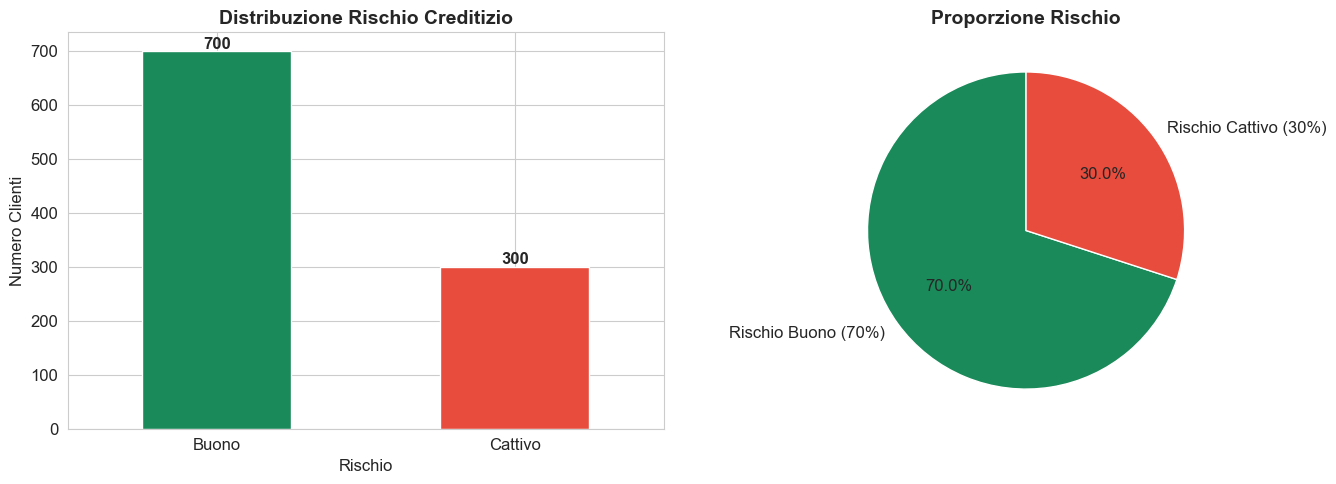

✅ Grafico salvato


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico a barre
colori = ['#1A8A5A', '#E74C3C']
df_clean['Risk'].value_counts().plot(
    kind='bar', ax=axes[0], color=colori, edgecolor='white'
)
axes[0].set_title('Distribuzione Rischio Creditizio', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rischio')
axes[0].set_ylabel('Numero Clienti')
axes[0].set_xticklabels(['Buono', 'Cattivo'], rotation=0)

for bar, val in zip(axes[0].patches, df_clean['Risk'].value_counts()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold')

# Grafico a torta
axes[1].pie(
    df_clean['Risk'].value_counts(),
    labels=['Rischio Buono (70%)', 'Rischio Cattivo (30%)'],
    colors=colori, autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 12}
)
axes[1].set_title('Proporzione Rischio', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../screenshots/01_distribuzione_rischio.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafico salvato")

C:\Users\jedwa\AppData\Local\Temp\ipykernel_28964\654168246.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Risk', y='Age',
C:\Users\jedwa\AppData\Local\Temp\ipykernel_28964\654168246.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Rischio Buono', 'Rischio Cattivo'])
C:\Users\jedwa\AppData\Local\Temp\ipykernel_28964\654168246.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Risk', y='Credit amount',
C:\Users\jedwa\AppData\Local\Temp\ipykernel_28964\654168246.py:14: UserWarning: set_ticklabels() should only be used with a fixed number 

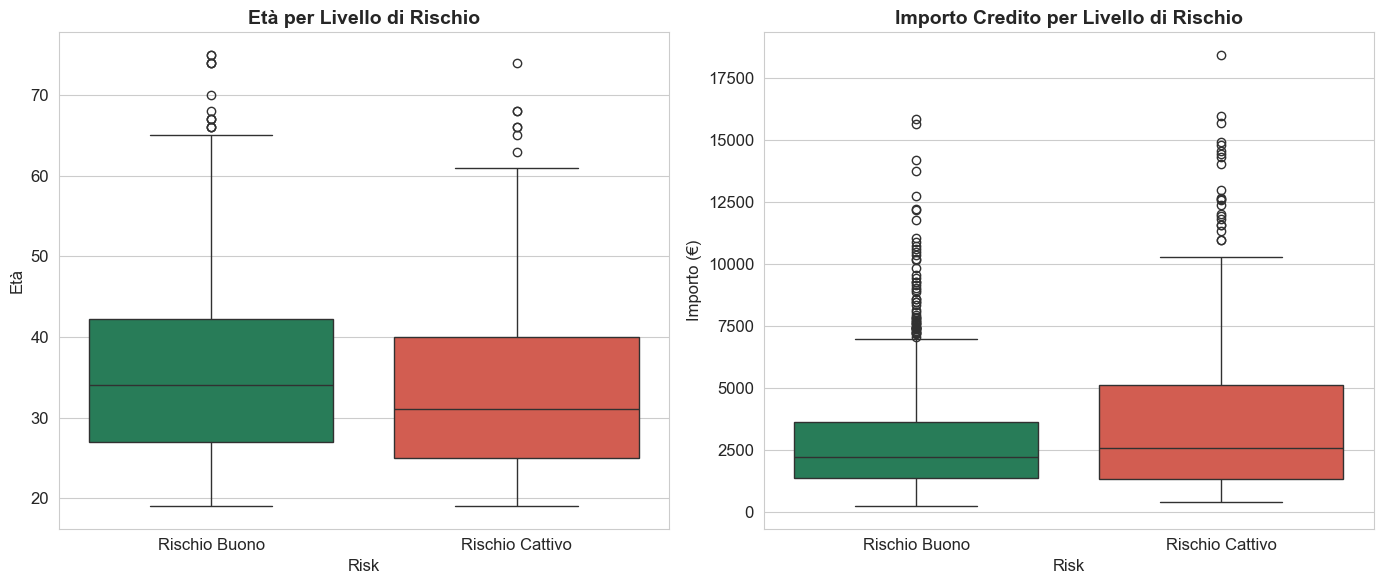

✅ Grafico salvato


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Età per rischio
sns.boxplot(data=df_clean, x='Risk', y='Age',
            palette=['#1A8A5A', '#E74C3C'], ax=axes[0])
axes[0].set_title('Età per Livello di Rischio', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Rischio Buono', 'Rischio Cattivo'])
axes[0].set_ylabel('Età')

# Importo credito per rischio
sns.boxplot(data=df_clean, x='Risk', y='Credit amount',
            palette=['#1A8A5A', '#E74C3C'], ax=axes[1])
axes[1].set_title('Importo Credito per Livello di Rischio', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Rischio Buono', 'Rischio Cattivo'])
axes[1].set_ylabel('Importo (€)')

plt.tight_layout()
plt.savefig('../screenshots/02_eta_importo_rischio.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafico salvato")

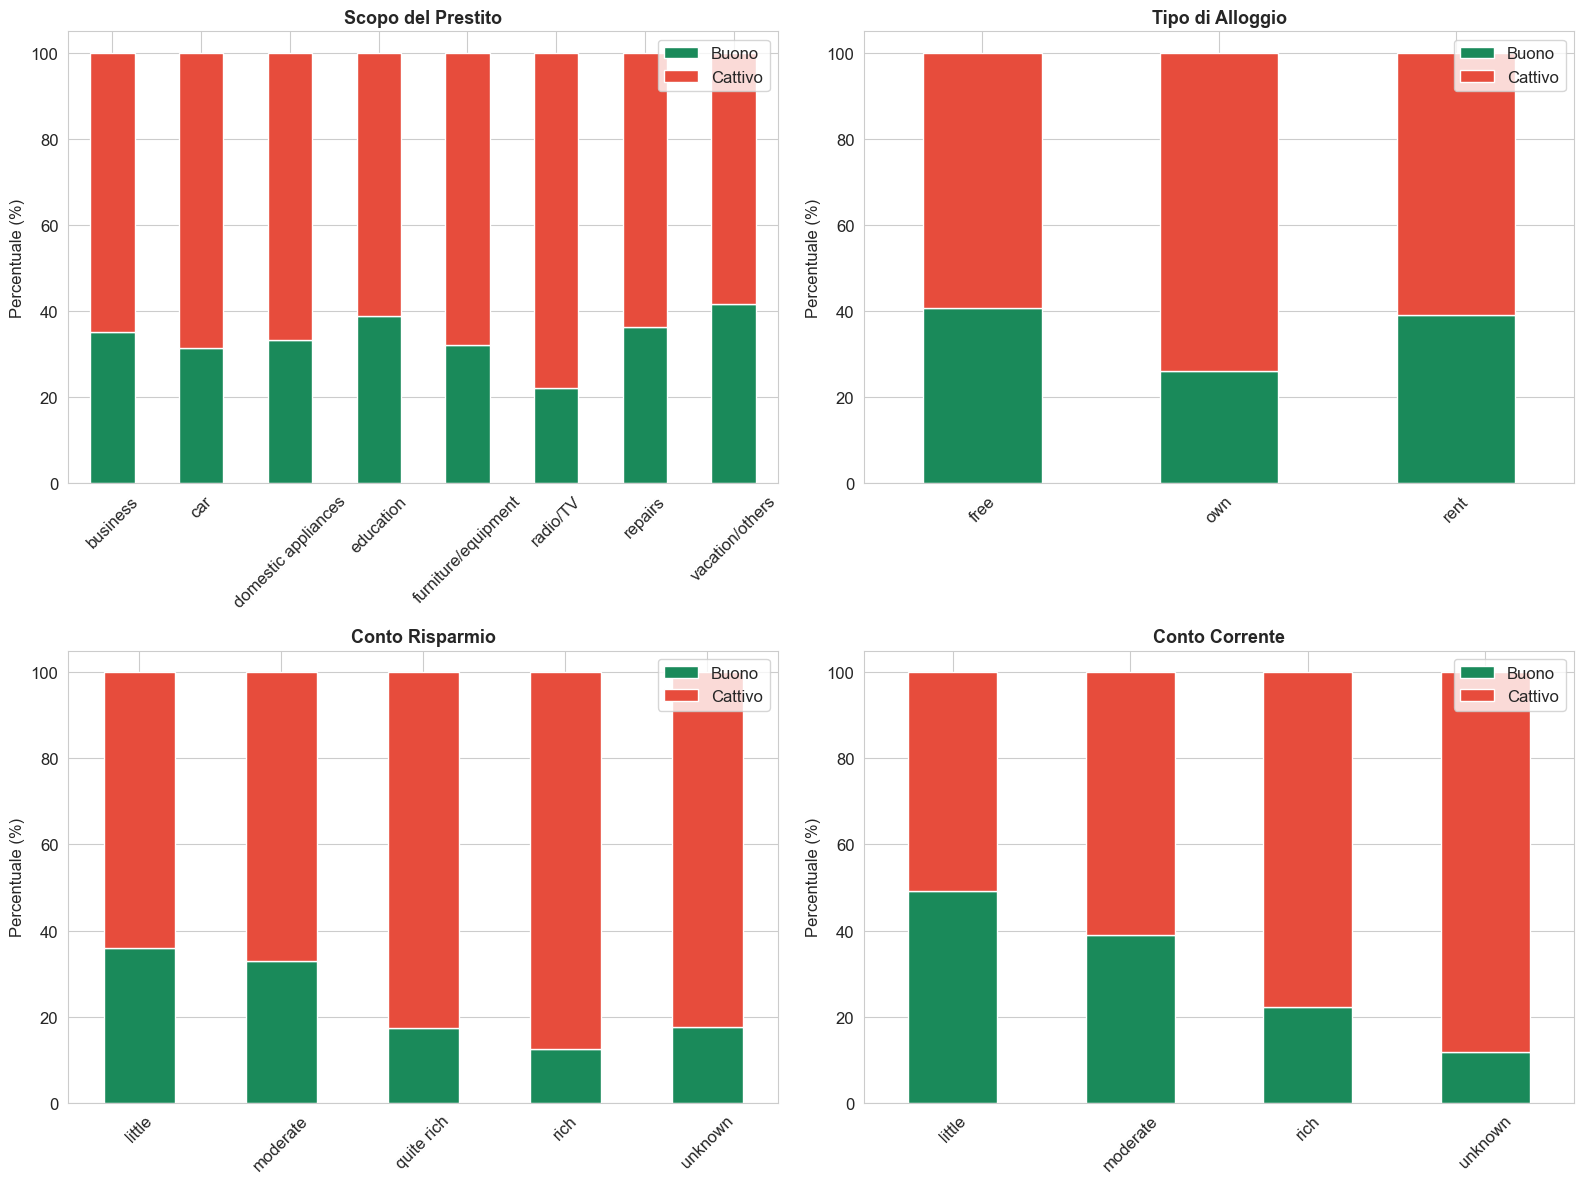

✅ Grafico salvato


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

categoriche = ['Purpose', 'Housing', 'Saving accounts', 'Checking account']
titoli = ['Scopo del Prestito', 'Tipo di Alloggio',
          'Conto Risparmio', 'Conto Corrente']

for ax, col, titolo in zip(axes.flatten(), categoriche, titoli):
    ct = pd.crosstab(df_clean[col], df_clean['Risk'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=['#1A8A5A', '#E74C3C'], edgecolor='white')
    ax.set_title(titolo, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Percentuale (%)')
    ax.legend(['Buono', 'Cattivo'], loc='upper right')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../screenshots/03_rischio_categoriche.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafico salvato")

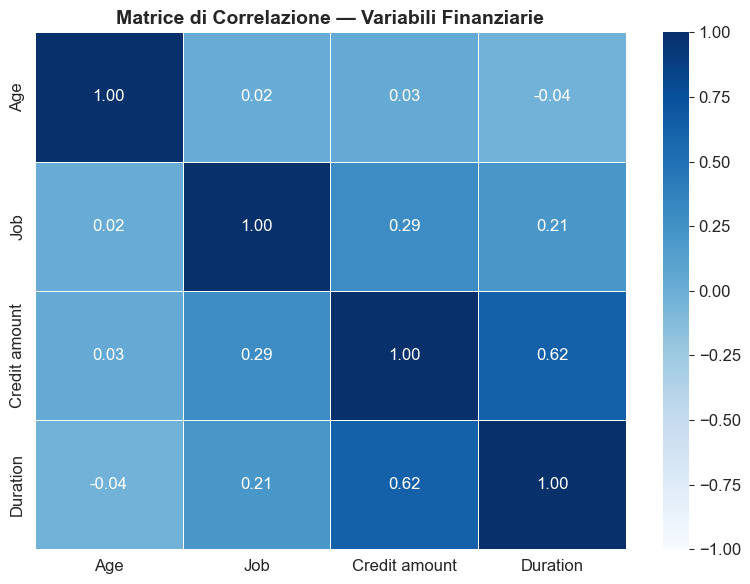

✅ Grafico salvato


In [11]:
# Solo variabili numeriche
numeriche = ['Age', 'Job', 'Credit amount', 'Duration']
corr = df_clean[numeriche].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matrice di Correlazione — Variabili Finanziarie',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/04_correlazione.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafico salvato")

## 4. Preparazione del Modello e Feature Engineering

In [12]:
df_model = df_clean.copy()

# Codifica variabili categoriche
le = LabelEncoder()
categoriche = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

for col in categoriche:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Target binario
df_model['Risk'] = df_model['Risk'].map({'good': 0, 'bad': 1})

# Feature Engineering — rapporto importo/durata
df_model['credit_duration_ratio'] = df_model['Credit amount'] / df_model['Duration']

print("✅ Variabili codificate")
print("\nShape dataset modello:", df_model.shape)
print("\nPrime 5 righe:")
print(df_model.head())

✅ Variabili codificate

Shape dataset modello: (1000, 11)

Prime 5 righe:
   Age  Sex  Job  Housing  Saving accounts  Checking account  Credit amount  \
0   67    1    2        1                4                 0           1169   
1   22    0    2        1                0                 1           5951   
2   49    1    1        1                0                 3           2096   
3   45    1    2        0                0                 0           7882   
4   53    1    2        0                0                 0           4870   

   Duration  Purpose  Risk  credit_duration_ratio  
0         6        5     0             194.833333  
1        48        5     1             123.979167  
2        12        3     0             174.666667  
3        42        4     0             187.666667  
4        24        1     1             202.916667  


In [13]:
X = df_model.drop('Risk', axis=1)
y = df_model['Risk']

# Divisione train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling — normalizzazione delle variabili numeriche
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Dati preparati per il modello")
print("Training:", X_train.shape)
print("Test:", X_test.shape)
print("\nFeatures utilizzate:")
for col in X.columns:
    print(f"  → {col}")

✅ Dati preparati per il modello
Training: (800, 10)
Test: (200, 10)

Features utilizzate:
  → Age
  → Sex
  → Job
  → Housing
  → Saving accounts
  → Checking account
  → Credit amount
  → Duration
  → Purpose
  → credit_duration_ratio


## 5. Addestramento e Valutazione dei Modelli

In [14]:
modelli = {
    'Regressione Logistica': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

risultati = []

for nome, modello in modelli.items():
    # Usiamo scaled solo per Regressione Logistica
    if nome == 'Regressione Logistica':
        modello.fit(X_train_scaled, y_train)
        y_pred = modello.predict(X_test_scaled)
        y_prob = modello.predict_proba(X_test_scaled)[:, 1]
    else:
        modello.fit(X_train, y_train)
        y_pred = modello.predict(X_test)
        y_prob = modello.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    risultati.append({
        'Modello': nome,
        'Accuracy': round(acc * 100, 1),
        'ROC-AUC': round(auc, 3)
    })

    print(f"\n=== {nome.upper()} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC:  {auc:.4f}")
    print(classification_report(y_test, y_pred,
          target_names=['Buono', 'Cattivo']))

df_risultati = pd.DataFrame(risultati)
print("\n=== CONFRONTO MODELLI ===")
print(df_risultati.to_string(index=False))


=== REGRESSIONE LOGISTICA ===
Accuracy: 0.7300
ROC-AUC:  0.7660
              precision    recall  f1-score   support

       Buono       0.78      0.86      0.82       140
     Cattivo       0.57      0.42      0.48        60

    accuracy                           0.73       200
   macro avg       0.67      0.64      0.65       200
weighted avg       0.71      0.73      0.72       200


=== RANDOM FOREST ===
Accuracy: 0.7550
ROC-AUC:  0.7749
              precision    recall  f1-score   support

       Buono       0.79      0.89      0.84       140
     Cattivo       0.63      0.45      0.52        60

    accuracy                           0.76       200
   macro avg       0.71      0.67      0.68       200
weighted avg       0.74      0.76      0.74       200


=== GRADIENT BOOSTING ===
Accuracy: 0.7650
ROC-AUC:  0.7801
              precision    recall  f1-score   support

       Buono       0.80      0.88      0.84       140
     Cattivo       0.64      0.50      0.56        60


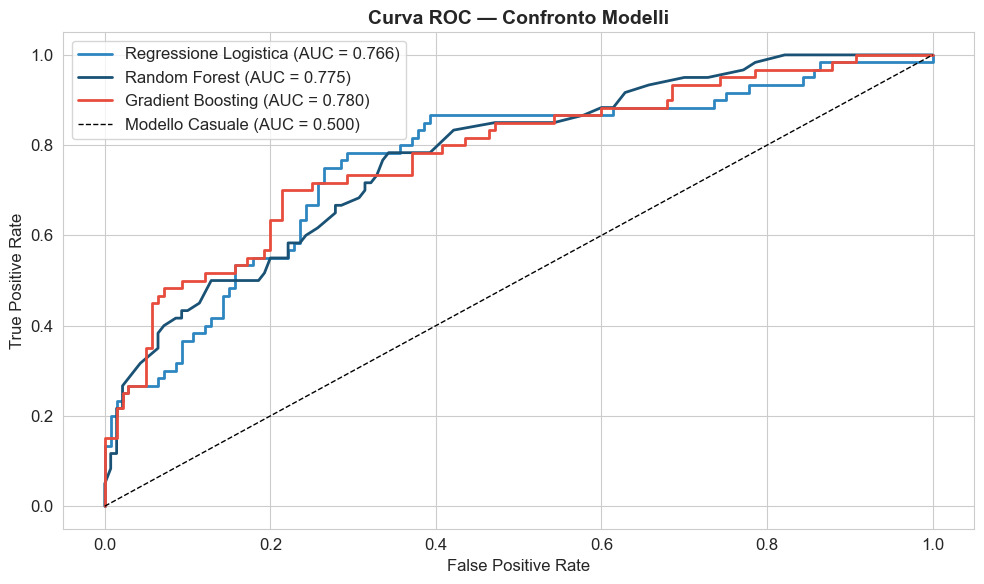

✅ Grafico salvato


In [15]:
plt.figure(figsize=(10, 6))

colori_modelli = ['#2E86C1', '#1A5276', '#E74C3C']

for (nome, modello), colore in zip(modelli.items(), colori_modelli):
    if nome == 'Regressione Logistica':
        y_prob = modello.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = modello.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=colore, linewidth=2,
             label=f'{nome} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Modello Casuale (AUC = 0.500)')
plt.title('Curva ROC — Confronto Modelli', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../screenshots/05_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafico salvato")

C:\Users\jedwa\AppData\Local\Temp\ipykernel_28964\2468279619.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importanza', y='Feature', palette='Blues_r')


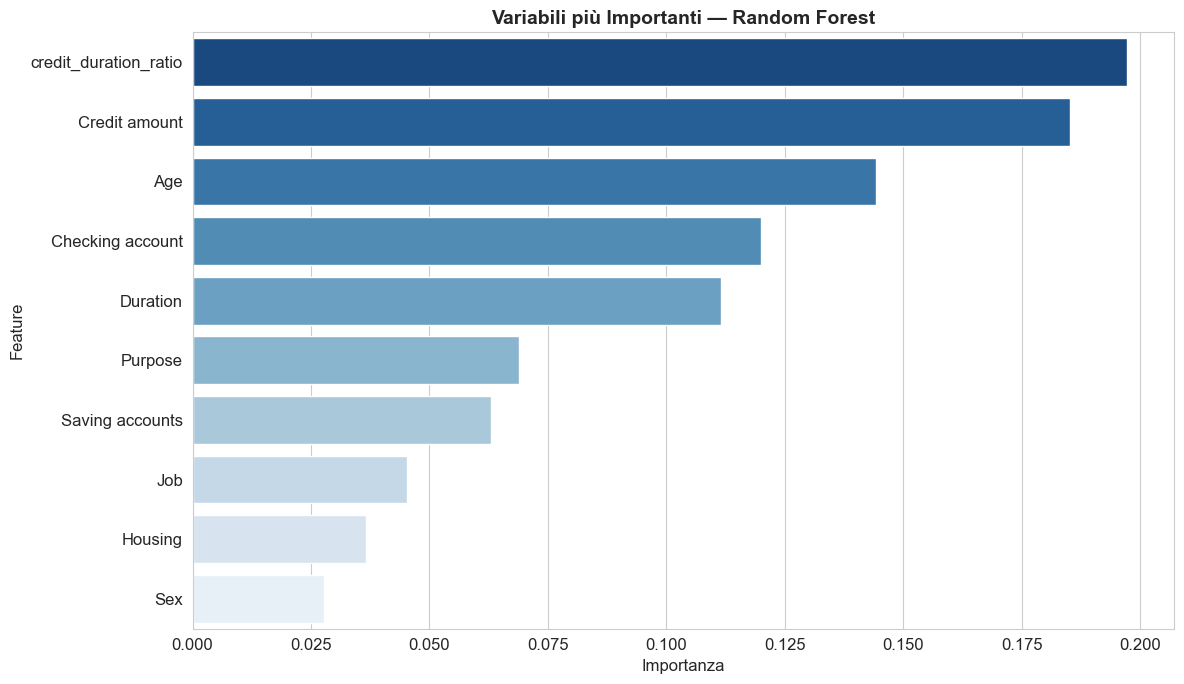

=== TOP 5 VARIABILI ===
              Feature  Importanza
credit_duration_ratio    0.197303
        Credit amount    0.185305
                  Age    0.144214
     Checking account    0.119914
             Duration    0.111552


In [16]:
# Usiamo Random Forest per la feature importance
rf = modelli['Random Forest']

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importanza': rf.feature_importances_
}).sort_values('Importanza', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=feature_importance, x='Importanza', y='Feature', palette='Blues_r')
plt.title('Variabili più Importanti — Random Forest',
          fontsize=14, fontweight='bold')
plt.xlabel('Importanza')
plt.tight_layout()
plt.savefig('../screenshots/06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== TOP 5 VARIABILI ===")
print(feature_importance.head(5).to_string(index=False))

## 6. Predizione su Nuovi Clienti

In [17]:
# Gradient Boosting — miglior modello
gb = modelli['Gradient Boosting']

# 3 profili clienti
# Ordine colonne: Age, Sex, Job, Housing, Saving accounts, 
#                 Checking account, Credit amount, Duration, 
#                 Purpose, credit_duration_ratio

nuovi_clienti = pd.DataFrame({
    'Age':                  [23,   45,   35],
    'Sex':                  [1,    0,    1],      # 1=male, 0=female
    'Job':                  [1,    3,    2],
    'Housing':              [2,    1,    0],      # 2=rent, 1=own, 0=free
    'Saving accounts':      [0,    3,    1],      # 0=little, 3=rich
    'Checking account':     [0,    2,    1],
    'Credit amount':        [8000, 3000, 5000],
    'Duration':             [48,   12,   24],
    'Purpose':              [1,    3,    4],
    'credit_duration_ratio':[8000/48, 3000/12, 5000/24]
})

predicciones = gb.predict(nuovi_clienti)
probabilita = gb.predict_proba(nuovi_clienti)[:, 1] * 100

profili = [
    "Giovane 23a, affitto, pochi risparmi, €8.000 x 48 mesi",
    "Adulto 45a, proprietario, risparmi alti, €3.000 x 12 mesi",
    "Medio 35a, casa libera, risparmi medi, €5.000 x 24 mesi"
]

print("=== VALUTAZIONE RISCHIO NUOVI CLIENTI ===\n")
for i, (pred, prob, profilo) in enumerate(zip(predicciones, probabilita, profili)):
    stato = "🔴 CREDITO A RISCHIO" if pred == 1 else "🟢 CREDITO APPROVABILE"
    print(f"Cliente {i+1}: {profilo}")
    print(f"  → {stato} | Probabilità rischio: {prob:.1f}%")
    print()

=== VALUTAZIONE RISCHIO NUOVI CLIENTI ===

Cliente 1: Giovane 23a, affitto, pochi risparmi, €8.000 x 48 mesi
  → 🔴 CREDITO A RISCHIO | Probabilità rischio: 83.3%

Cliente 2: Adulto 45a, proprietario, risparmi alti, €3.000 x 12 mesi
  → 🟢 CREDITO APPROVABILE | Probabilità rischio: 20.0%

Cliente 3: Medio 35a, casa libera, risparmi medi, €5.000 x 24 mesi
  → 🟢 CREDITO APPROVABILE | Probabilità rischio: 36.3%



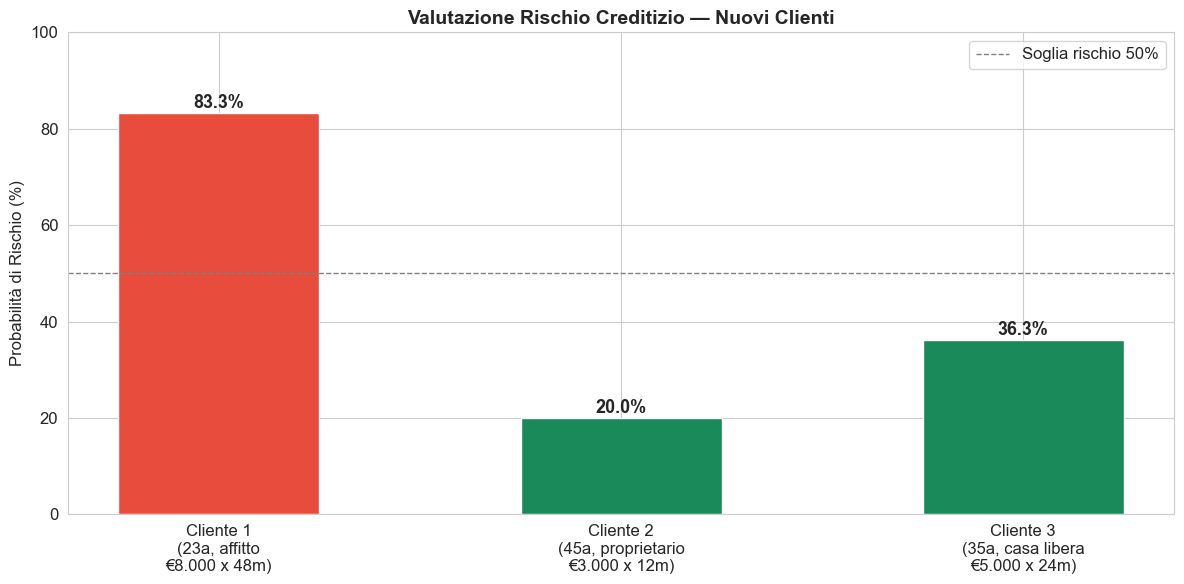

✅ Grafico salvato


In [18]:
clienti = ['Cliente 1\n(23a, affitto\n€8.000 x 48m)',
           'Cliente 2\n(45a, proprietario\n€3.000 x 12m)',
           'Cliente 3\n(35a, casa libera\n€5.000 x 24m)']

colori = ['#E74C3C' if p == 1 else '#1A8A5A' for p in predicciones]

plt.figure(figsize=(12, 6))
bars = plt.bar(clienti, probabilita, color=colori, edgecolor='white', width=0.5)

for bar, prob in zip(bars, probabilita):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{prob:.1f}%', ha='center', fontsize=13, fontweight='bold')

plt.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='Soglia rischio 50%')
plt.title('Valutazione Rischio Creditizio — Nuovi Clienti',
          fontsize=14, fontweight='bold')
plt.ylabel('Probabilità di Rischio (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.savefig('../screenshots/07_predizioni_clienti.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafico salvato")

In [19]:
# Dataset processato
df_model.to_csv('../data/credit_clean.csv', index=False)

# Risultati modelli
df_risultati.to_csv('../data/model_results.csv', index=False)

# Feature importance
feature_importance.to_csv('../data/feature_importance.csv', index=False)

print("✅ File salvati:")
print("   - data/credit_clean.csv")
print("   - data/model_results.csv")
print("   - data/feature_importance.csv")
print(f"\n✅ Screenshot salvati: 7 grafici in screenshots/")
print("\n✅ Analisi Python completata!")

✅ File salvati:
   - data/credit_clean.csv
   - data/model_results.csv
   - data/feature_importance.csv

✅ Screenshot salvati: 7 grafici in screenshots/

✅ Analisi Python completata!


## 7. Conclusioni

| Insight | Valore |
|---------|--------|
| Clienti analizzati | 1.000 |
| Distribuzione rischio | 70% buono / 30% cattivo |
| Miglior modello | Gradient Boosting (AUC: 0.780) |
| Variabile più predittiva | credit_duration_ratio (19.7%) |
| Cliente più rischioso | Giovane, affitto, importo alto (83.3%) |
| Cliente più sicuro | Adulto, proprietario, importo basso (20.0%) |

In [20]:
# Esportiamo dataset con valori originali per Power BI
df_powerbi = df_clean.copy()
df_powerbi['Risk_label'] = df_powerbi['Risk'].map({0: 'Buono', 1: 'Cattivo'})
df_powerbi.to_csv('../data/credit_powerbi.csv', index=False)

print("✅ File per Power BI salvato con valori originali")
print(df_powerbi['Housing'].value_counts())
print(df_powerbi['Risk_label'].value_counts())

✅ File per Power BI salvato con valori originali
Housing
own     713
rent    179
free    108
Name: count, dtype: int64
Series([], Name: count, dtype: int64)


In [21]:
print("Valori Risk_label:")
print(df_powerbi['Risk_label'].unique())
print("\nValori Housing:")
print(df_powerbi['Housing'].unique())
print("\nValori Purpose:")
print(df_powerbi['Purpose'].unique())
print("\nValori Saving accounts:")
print(df_powerbi['Saving accounts'].unique())
print("\nValori Checking account:")
print(df_powerbi['Checking account'].unique())
print("\nValori Sex:")
print(df_powerbi['Sex'].unique())

Valori Risk_label:
[nan]

Valori Housing:
['own' 'free' 'rent']

Valori Purpose:
['radio/TV' 'education' 'furniture/equipment' 'car' 'business'
 'domestic appliances' 'repairs' 'vacation/others']

Valori Saving accounts:
['unknown' 'little' 'quite rich' 'rich' 'moderate']

Valori Checking account:
['little' 'moderate' 'unknown' 'rich']

Valori Sex:
['male' 'female']


In [23]:
# Ricarichiamo il dataset originale per avere i valori corretti
df_original = pd.read_csv('../data/credit_data.csv')

# Pulizia valori nulli
df_original['Saving accounts'] = df_original['Saving accounts'].fillna('unknown')
df_original['Checking account'] = df_original['Checking account'].fillna('unknown')

# Feature engineering
df_original['credit_duration_ratio'] = df_original['Credit amount'] / df_original['Duration']

# Verifica valori Risk originali
print("Valori Risk originali:")
print(df_original['Risk'].unique())

# Esportiamo per Power BI con tutti i valori in testo
df_powerbi = df_original.copy()
df_powerbi.to_csv('../data/credit_powerbi.csv', index=False)

print("\n✅ File credit_powerbi.csv rigenerato correttamente")
print("Shape:", df_powerbi.shape)
print("\nVerifica colonne chiave:")
print("Risk:", df_powerbi['Risk'].unique())
print("Housing:", df_powerbi['Housing'].unique())
print("Sex:", df_powerbi['Sex'].unique())

Valori Risk originali:
['good' 'bad']

✅ File credit_powerbi.csv rigenerato correttamente
Shape: (1000, 12)

Verifica colonne chiave:
Risk: ['good' 'bad']
Housing: ['own' 'free' 'rent']
Sex: ['male' 'female']


In [24]:
import os
import pandas as pd

# Verifica che il file esista
path = '../data/credit_powerbi.csv'
print("File esiste:", os.path.exists(path))

# Carica e verifica
df_check = pd.read_csv(path)
print("Shape:", df_check.shape)
print("Colonne:", df_check.columns.tolist())
print("\nPrime 3 righe:")
print(df_check.head(3))

File esiste: True
Shape: (1000, 12)
Colonne: ['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk', 'credit_duration_ratio']

Prime 3 righe:
   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own         unknown           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little          unknown   

   Credit amount  Duration    Purpose  Risk  credit_duration_ratio  
0           1169         6   radio/TV  good             194.833333  
1           5951        48   radio/TV   bad             123.979167  
2           2096        12  education  good             174.666667  


In [25]:
# Eliminiamo la colonna Unnamed: 0 e rigeneramo il file
df_powerbi = df_original[['Age', 'Sex', 'Job', 'Housing', 
                           'Saving accounts', 'Checking account',
                           'Credit amount', 'Duration', 'Purpose', 
                           'Risk', 'credit_duration_ratio']].copy()

df_powerbi.to_csv('../data/credit_powerbi.csv', index=False)

print("✅ File rigenerato senza colonne extra")
print("Colonne:", df_powerbi.columns.tolist())
print("Shape:", df_powerbi.shape)

✅ File rigenerato senza colonne extra
Colonne: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk', 'credit_duration_ratio']
Shape: (1000, 11)


In [26]:
# Forziamo i tipi corretti prima di esportare
df_powerbi = df_original[['Age', 'Sex', 'Job', 'Housing', 
                           'Saving accounts', 'Checking account',
                           'Credit amount', 'Duration', 'Purpose', 
                           'Risk', 'credit_duration_ratio']].copy()

# Convertiamo esplicitamente a numerico
df_powerbi['Age'] = pd.to_numeric(df_powerbi['Age'], errors='coerce')
df_powerbi['Job'] = pd.to_numeric(df_powerbi['Job'], errors='coerce')
df_powerbi['Credit amount'] = pd.to_numeric(df_powerbi['Credit amount'], errors='coerce')
df_powerbi['Duration'] = pd.to_numeric(df_powerbi['Duration'], errors='coerce')
df_powerbi['credit_duration_ratio'] = pd.to_numeric(df_powerbi['credit_duration_ratio'], errors='coerce')

# Verifica tipi
print("Tipi di dati:")
print(df_powerbi.dtypes)
print("\nValori nulli:")
print(df_powerbi.isnull().sum())

# Esportiamo
df_powerbi.to_csv('../data/credit_powerbi.csv', index=False)
print("\n✅ File esportato con tipi corretti")

Tipi di dati:
Age                        int64
Sex                       object
Job                        int64
Housing                   object
Saving accounts           object
Checking account          object
Credit amount              int64
Duration                   int64
Purpose                   object
Risk                      object
credit_duration_ratio    float64
dtype: object

Valori nulli:
Age                      0
Sex                      0
Job                      0
Housing                  0
Saving accounts          0
Checking account         0
Credit amount            0
Duration                 0
Purpose                  0
Risk                     0
credit_duration_ratio    0
dtype: int64

✅ File esportato con tipi corretti
